# 01 State 深入：数据怎么流转（Reducer / 并行冲突 / superstep）

## 本章学什么

- 为什么“两个节点同时写同一个字段”会报错（并行 superstep 冲突）
- Reducer 是什么：它决定 update 如何合并回 state
- 最常见的 reducer：`operator.add`（列表追加）
- `add_messages` / `MessagesState` 的直觉：为什么对话消息需要“更聪明的合并”

## 解决什么问题

你在 00 章已经理解了 State/Node/Edge，但你可能会困惑：

- 我把流程拆成并行分支后，为什么突然报错？
- 为什么有时 state 会覆盖，有时又能“累积/追加”？

本章用最小例子把“状态合并规则”讲清楚。

## 学完能做什么

- 看到 `InvalidUpdateError` 你能立刻判断：是 reducer 缺失导致的并行写冲突
- 你能用 `Annotated[..., reducer]` 给 state 字段定义合并规则
- 你能解释 `add_messages` 相比简单 `list + list` 多了什么能力


## 目录

- 一、回顾：State 是字典，Node 返回 update
- 二、一个会出错的场景：并行写同一个字段
- 三、Reducer 是什么：合并规则
- 四、Demo 1：复现报错（无 reducer）
- 五、Demo 2：修复报错（用 `operator.add` 追加）
- 六、Demo 3：从列表追加到消息合并（`add_messages`）
- 七、常见坑
- 八、小结


## 一、回顾：State 是字典，Node 返回 update

在 00 章里我们已经建立了直觉：

- **State**：一张共享的“单子”（字典）
- **Node**：一个步骤（函数），输入 state，输出 **增量 update（字典）**
- **LangGraph**：把 node 输出的 update 合并回 state，然后沿着边继续执行

这一章只把一个问题讲透：

> **当“同一步”里有多个 node 同时写同一个 state 字段时，LangGraph 应该怎么合并？**


## 二、一个会出错的场景：并行写同一个字段

假设我们做一个“客服系统”，需要同时做两件事：

- 查订单状态
- 查用户历史

它们互不依赖，所以很自然想并行执行：

```text
START
  ├─ 查订单
  └─ 查历史
        ↓
      汇总
END
```

但如果两个并行节点都写 `result` 这个字段，会发生什么？

下面我们用最小代码**故意复现报错**。

## 三、Reducer 是什么：合并规则

当 node 返回 update 时，LangGraph 要把 update 合并回 state。

- 对于很多字段（比如 `status`），你通常希望**新值覆盖旧值**。
- 但对于并行结果收集（比如多个搜索结果），你希望**把多个新值合并起来**。

Reducer 就是“合并规则”：

> `reducer(旧值, 新值) -> 合并后的值`

在 Python 类型里，LangGraph 通常用 `Annotated` 把 reducer 贴在字段上：

```python
from typing import Annotated
from operator import add

results: Annotated[list[str], add]
```

`operator.add` 对列表的含义就是：

```python
old_list + new_list
```

也就是“追加”。

In [1]:
from __future__ import annotations

import operator
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END

print("准备完成")

准备完成


## 四、Demo 1：复现报错（无 reducer）

这一格代码**会报错**，而且是我们想要的效果：

- 两个并行节点同一步都写 `result`
- LangGraph 不知道怎么合并，所以抛异常

你运行后看到报错，再继续往下看“怎么修”。

In [2]:
class BadState(TypedDict):
    # 注意：这里没有 reducer
    result: str


def fetch_order(_: BadState):
    return {"result": "订单：已发货"}


def fetch_history(_: BadState):
    return {"result": "历史：最近一次咨询在昨天"}


def joiner(state: BadState):
    # 这个节点其实执行不到（因为上一步就冲突了）
    return {"result": state["result"] + " | 汇总完成"}


builder = StateGraph(BadState)
builder.add_node("fetch_order", fetch_order)
builder.add_node("fetch_history", fetch_history)
builder.add_node("join", joiner)

# 并行 fan-out
builder.add_edge(START, "fetch_order")
builder.add_edge(START, "fetch_history")

# fan-in
builder.add_edge("fetch_order", "join")
builder.add_edge("fetch_history", "join")

builder.add_edge("join", END)

bad_graph = builder.compile()

# 运行这行：你会看到 InvalidUpdateError（这是预期的）
bad_graph.invoke({"result": ""})

InvalidUpdateError: At key 'result': Can receive only one value per step. Use an Annotated key to handle multiple values.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_CONCURRENT_GRAPH_UPDATE

### 你刚刚看见的报错在说什么？（补充说明）

把这段话牢牢记住就够了：

- 并行分支在**同一个 superstep** 里同时产出 update
- 如果它们写的是**同一个 key**（比如都写 `result`）
- 又**没有 reducer** 告诉 LangGraph “怎么把两个值合起来”
- 就会报 `InvalidUpdateError`

接下来我们把 state 的 `result` 改成 `results: list[str]`，并加上 `operator.add` 作为 reducer。


## 五、Demo 2：修复报错（用 `operator.add` 追加）

我们做两件事：

- `result: str` → `results: list[str]`
- 给 `results` 加上 reducer：`Annotated[list[str], operator.add]`

然后用 `stream_mode="updates"` 和 `"values"` 看清楚：

- 每个 node **到底返回了什么 update**
- LangGraph **合并后的 state 长什么样**


In [5]:
class GoodState(TypedDict):
    # 关键：告诉 LangGraph 如何合并并行 update
    results: Annotated[list[str], operator.add]


def fetch_order_good(_: GoodState):
    return {"results": ["订单：已发货"]}


def fetch_history_good(_: GoodState):
    return {"results": ["历史：最近一次咨询在昨天"]}


def join_good(state: GoodState):
    # join 节点可以读到并行汇总后的 results
    merged = " | ".join(state["results"])
    return {"results": [f"汇总：{merged}"]}


builder2 = StateGraph(GoodState)
builder2.add_node("fetch_order", fetch_order_good)
builder2.add_node("fetch_history", fetch_history_good)
builder2.add_node("join", join_good)

builder2.add_edge(START, "fetch_order")
builder2.add_edge(START, "fetch_history")

builder2.add_edge("fetch_order", "join")
builder2.add_edge("fetch_history", "join")

builder2.add_edge("join", END)

good_graph = builder2.compile()

init_state = {"results": []}
final_state = good_graph.invoke(init_state)
final_state

{'results': ['历史：最近一次咨询在昨天', '订单：已发货', '汇总：历史：最近一次咨询在昨天 | 订单：已发货']}

In [6]:
print("=== stream_mode=updates：看每个节点返回的增量 update ===")
for event in good_graph.stream({"results": []}, stream_mode="updates"):
    print(event)

print("\n=== stream_mode=values：看每一步合并后的完整 state ===")
for event in good_graph.stream({"results": []}, stream_mode="values"):
    print(event)

=== stream_mode=updates：看每个节点返回的增量 update ===
{'fetch_history': {'results': ['历史：最近一次咨询在昨天']}}
{'fetch_order': {'results': ['订单：已发货']}}
{'join': {'results': ['汇总：历史：最近一次咨询在昨天 | 订单：已发货']}}

=== stream_mode=values：看每一步合并后的完整 state ===
{'results': []}
{'results': ['历史：最近一次咨询在昨天', '订单：已发货']}
{'results': ['历史：最近一次咨询在昨天', '订单：已发货', '汇总：历史：最近一次咨询在昨天 | 订单：已发货']}


### 你应该观察到什么？（补充说明）

- `updates` 里你会看到两个并行节点分别返回：
  - `{"fetch_order": {"results": ["..."]}}`
  - `{"fetch_history": {"results": ["..."]}}`
- `values` 里你会看到合并后的 state：
  - `{"results": ["订单...", "历史..."]}`

注意一个细节：并行分支的到达顺序不保证固定，所以 `results` 的顺序可能变化。


### （可选）把这张图画出来（PNG）

运行下面这一格，会在 notebook 里显示图。

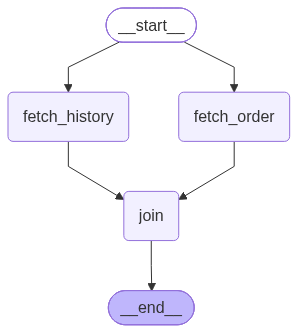

In [8]:
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod


display(
    Image(
        good_graph.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

## 六、Demo 3：从列表追加到消息合并（`add_messages`）

你已经理解了“并行结果收集用 `operator.add` 合并 list”。

那为什么 `MessagesState` 不直接用 `operator.add`？

原因是：对话消息的合并需求更复杂：

- 不是只有“追加”，还需要“按消息 id 替换/删除”
- 要能让多轮对话在 state 里稳定地增长（并且可控）

LangGraph 为此提供了 `add_messages` 这个更聪明的 reducer。

下面我们不引入任何 LLM，只用纯消息对象来观察它的合并行为。

In [9]:
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, AIMessage

m1 = HumanMessage(content="你好", id="m1")
m2 = AIMessage(content="我能帮你做什么？", id="m2")

old = [m1]
new = [m2]
merged = add_messages(old, new)

print("old:", [(m.type, m.id, m.content) for m in old])
print("new:", [(m.type, m.id, m.content) for m in new])
print("merged:", [(m.type, m.id, m.content) for m in merged])

old: [('human', 'm1', '你好')]
new: [('ai', 'm2', '我能帮你做什么？')]
merged: [('human', 'm1', '你好'), ('ai', 'm2', '我能帮你做什么？')]


### 观察 1：同 id 的消息会“替换”，而不是盲目追加

这就是 `add_messages` 比 `operator.add` 更“聪明”的地方：

- `operator.add` 只会拼接列表
- `add_messages` 会按消息 `id` 做“更新/替换”的语义


In [10]:
m2_new = AIMessage(content="我可以帮你查订单、写总结。", id="m2")
merged2 = add_messages(merged, [m2_new])

print("before:", [(m.type, m.id, m.content) for m in merged])
print("after :", [(m.type, m.id, m.content) for m in merged2])

before: [('human', 'm1', '你好'), ('ai', 'm2', '我能帮你做什么？')]
after : [('human', 'm1', '你好'), ('ai', 'm2', '我可以帮你查订单、写总结。')]


### 观察 2：为什么说它还能“删除/替换”？（补充说明）

你刚刚已经看到 **同 id 会替换**。

至于“删除”，`add_messages` 还支持用特定的“删除指令消息”按 id 移除旧消息（不同版本的消息类名称可能略有差异）。

本章先不展开删除的代码演示，避免被版本差异分散注意力：你只要记住结论——**它不仅能追加，还能按 id 做更新语义**。

### 从这里到 `MessagesState`

`MessagesState` 的核心思想你现在已经有了：

- state 里有一个 `messages: list[...]`
- 这个字段的 reducer 不是 `operator.add`，而是 `add_messages`

所以它能支持：追加、替换、删除、以及更稳定的多轮对话合并。

## 七、常见坑

- **并行分支写同一个 key**：没有 reducer 就会 `InvalidUpdateError`
- **用 `operator.add` 时，update 必须返回“同类型”**：
  - 字段是 `list[str]`，update 也必须是 `list[str]`（别返回单个 `str`）
- **并行顺序不保证**：如果你依赖顺序，建议在 `join` 节点里排序或显式标注来源
- **Reducer 不是“魔法自动合并所有字段”**：它只对你标注的那个字段生效
- **`MessagesState` 用的是 `add_messages`**：不要把它当成简单的 `list + list`


## 八、小结

这一章你掌握了 LangGraph 里最关键但也最容易忽略的一点：

- Node 返回的是 **update（增量）**，不是整个 state
- 并行 superstep 下，如果多个 update 写同一个 key：
  - **没有 reducer** → 报错
  - **有 reducer** → 按规则合并
- `operator.add` 适合“并行收集列表结果”
- `add_messages` 适合“对话消息的稳定合并”（追加/替换/删除）

下一章我们会专门讲：**条件路由模式**（让图“像程序一样 if/else 跑起来”）。
